# Практическая работа 4.2. RNN

Выполнение задания.


## Задание

Получить точность классификации более 92%. Например, с помощью увеличения числа слов, участвующих в обучении, настройки параметров сети и тд.


In [1]:
from __future__ import annotations

import os
import random
from pathlib import Path

PRACTICE_DIR = Path.cwd()

CACHE_DIR = PRACTICE_DIR / ".cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(CACHE_DIR / "matplotlib")
os.environ["IPYTHONDIR"] = str(CACHE_DIR / "ipython")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

DATA_DIR = PRACTICE_DIR / ".data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
os.environ["KERAS_HOME"] = str(DATA_DIR / "keras_home")

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import (
    Bidirectional,
    Dense,
    Dropout,
    Embedding,
    GlobalMaxPooling1D,
    Input,
    LSTM,
    SpatialDropout1D,
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.set_visible_devices([], "GPU")


In [2]:
def plot_training_history(history, title_prefix: str) -> None:
    """Строит графики точности и потерь по объекту History из Keras."""
    history_dict = history.history
    acc_key = "acc" if "acc" in history_dict else "accuracy"
    val_acc_key = "val_acc" if "val_acc" in history_dict else "val_accuracy"

    acc = history_dict[acc_key]
    val_acc = history_dict[val_acc_key]
    loss = history_dict["loss"]
    val_loss = history_dict["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure()
    plt.plot(epochs, acc, "bo", label="Training acc")
    plt.plot(epochs, val_acc, "b", label="Validation acc")
    plt.title(f"{title_prefix}: training and validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.figure()
    plt.plot(epochs, loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title(f"{title_prefix}: training and validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


In [3]:
max_features = 20000
maxlen = 500
batch_size = 64

(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
input_train = pad_sequences(input_train, maxlen=maxlen)
input_test = pad_sequences(input_test, maxlen=maxlen)

print("input_train shape:", input_train.shape)
print("input_test shape:", input_test.shape)


input_train shape: (25000, 500)
input_test shape: (25000, 500)


За основу взята более сильная схема с двунаправленным `LSTM`, `SpatialDropout1D` и `GlobalMaxPooling1D`. Для добора качества увеличены размерность скрытого слоя и добавлена L2-регуляризация полносвязного слоя. Контролируется именно максимальная точность на проверочной выборке.


In [4]:
model = Sequential(
    [
        Input(shape=(maxlen,)),
        Embedding(max_features, 128),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(96, return_sequences=True, dropout=0.2)),
        GlobalMaxPooling1D(),
        Dense(128, activation="relu", kernel_regularizer=l2(1e-4)),
        Dropout(0.45),
        Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4),
    loss="binary_crossentropy",
    metrics=["acc"],
)

callbacks = [
    EarlyStopping(
        monitor="val_acc",
        patience=3,
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
    ),
]

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 500, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 500, 192)       │       172,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 192)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,757,633 (10.52 MB)

 Trainable params: 2,757,633 (10.52 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    input_train,
    y_train,
    epochs=12,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 248s 703ms/step - acc: 0.7814 - loss: 0.4359 - val_acc: 0.8680 - val_loss: 0.3183 - learning_rate: 8.0000e-04
Epoch 2/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 249s 707ms/step - acc: 0.9162 - loss: 0.2229 - val_acc: 0.8892 - val_loss: 0.2726 - learning_rate: 8.0000e-04
Epoch 3/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 250s 709ms/step - acc: 0.9424 - loss: 0.1654 - val_acc: 0.8392 - val_loss: 0.4380 - learning_rate: 8.0000e-04
Epoch 4/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 255s 724ms/step - acc: 0.9708 - loss: 0.0939 - val_acc: 0.8992 - val_loss: 0.3172 - learning_rate: 4.0000e-04
Epoch 5/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 254s 722ms/step - acc: 0.9859 - loss: 0.0542 - val_acc: 0.9000 - val_loss: 0.3825 - learning_rate: 2.0000e-04
Epoch 6/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 242s 686ms/step - acc: 0.9913 - loss: 0.0395 - val_acc: 0.8960 - val_loss: 0.4168 - learning_rate: 1.0000e-04
Epoch 7/12
352/352 ━━━━━━━━━━━━━━━━━━━━ 243s 691ms/step - acc: 0.9933 - loss: 0.0341 - val_acc: 0.89

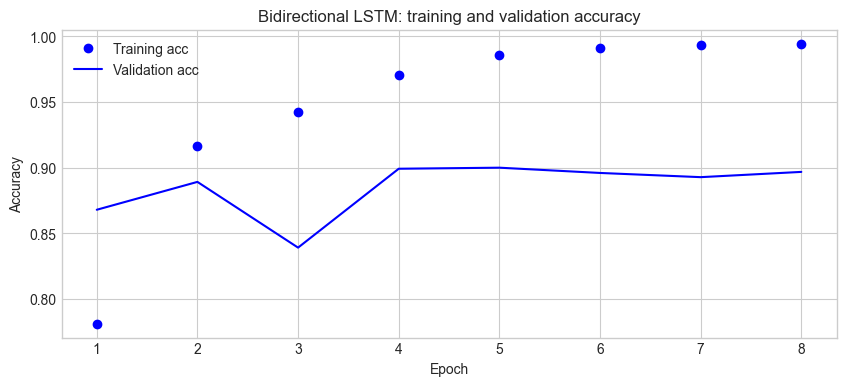

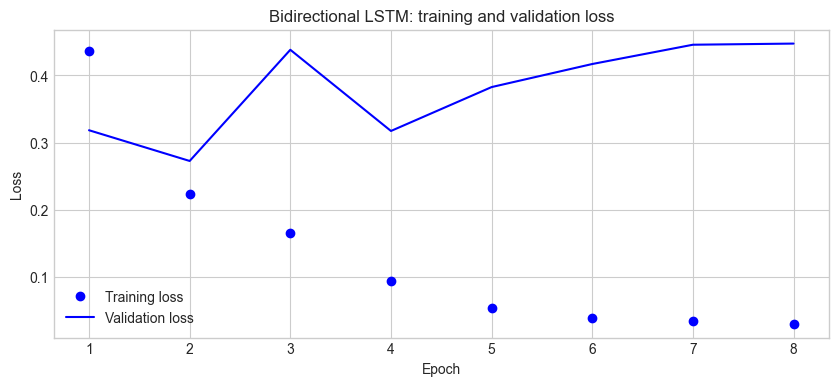

In [6]:
plot_training_history(history, "Bidirectional LSTM")


In [7]:
best_train_accuracy = max(history.history["acc"])
best_validation_accuracy = max(history.history["val_acc"])

print(f"Максимальная точность на обучении: {best_train_accuracy:.4f}")
print(f"Максимальная точность на проверке: {best_validation_accuracy:.4f}")


Максимальная точность на обучении: 0.9944
Максимальная точность на проверке: 0.9000
